In [ ]:
from google.colab import drive
import zipfile
import os
from pathlib import Path

# Mount Google Drive (force remount to ensure fresh connection)
drive.mount('/content/drive', force_remount=True)

# Define paths
ZIP_PATH = Path("/content/drive/MyDrive/Dataset/NurseStress.zip")
EXTRACT_BASE = Path("/content/Stress_dataset")
TEMP_EXTRACT = Path("/content/temp_extract")  # Temporary directory for inner Stress_dataset.zip
ORGANIZED_DIR = Path("/content/Stress_dataset/extracted")

# Step 1: Extract main NurseStress.zip
print("Extracting main dataset...")
with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
    zip_ref.extractall(EXTRACT_BASE)
print(f"✅ Extracted: {ZIP_PATH} -> {EXTRACT_BASE}")

# Debug: Verify the contents of the extracted directory
print("\nDebug: Checking contents of extracted directory...")
extracted_contents = list(EXTRACT_BASE.glob("**/*"))
if not extracted_contents:
    print("Error: No files found in extracted directory. Check if NurseStress.zip is empty or corrupted.")
else:
    print("Extracted files/folders (first 10):")
    for item in extracted_contents[:10]:
        print(item)

# Step 2: Check for Stress_dataset.zip and extract it
nested_zip = EXTRACT_BASE / "Stress_dataset.zip"
if nested_zip.exists():
    print(f"\nFound nested Stress_dataset.zip, extracting to temporary directory...")
    TEMP_EXTRACT.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(nested_zip, 'r') as zip_ref:
        zip_ref.extractall(TEMP_EXTRACT)
    print(f"✅ Extracted: {nested_zip} -> {TEMP_EXTRACT}")

    # Update EXTRACT_BASE to point to the temporary directory
    EXTRACT_BASE = TEMP_EXTRACT
else:
    print("\nNo Stress_dataset.zip found, proceeding with current extracted structure...")

# Debug: Verify the contents after extracting Stress_dataset.zip
print("\nDebug: Checking contents after extracting nested Stress_dataset.zip...")
extracted_contents = list(EXTRACT_BASE.glob("**/*"))
if not extracted_contents:
    print("Error: No files found after extracting Stress_dataset.zip.")
else:
    print("Extracted files/folders (first 10):")
    for item in extracted_contents[:10]:
        print(item)

# Debug: Look for nested .zip files in the updated EXTRACT_BASE
nested_zips = list(EXTRACT_BASE.glob("**/*.zip"))
print(f"\nDebug: Found {len(nested_zips)} nested .zip files:")
for z in nested_zips[:5]:
    print(z)

# Step 3: Recursively extract all inner ZIPs from each nurse folder
if not nested_zips:
    print("Error: No nested .zip files found to extract. Please verify the structure of NurseStress.zip.")
else:
    print("\nExtracting all nested .zip files...")
    for file_path in nested_zips:
        try:
            # Determine the nurse ID and session folder
            relative_path = Path(file_path).relative_to(EXTRACT_BASE)
            parts = relative_path.parts
            if len(parts) >= 2:  # Ensure there's at least nurse_id and session zip
                nurse_id = parts[-2]  # e.g., '15'
                session_folder = Path(file_path).stem  # e.g., '15_1594140175'
                session_extract_path = ORGANIZED_DIR / nurse_id / session_folder
                session_extract_path.mkdir(parents=True, exist_ok=True)

                # Extract inner session ZIP
                print(f"Extracting {file_path} to {session_extract_path}...")
                with zipfile.ZipFile(file_path, 'r') as inner_zip:
                    inner_zip.extractall(session_extract_path)
            else:
                print(f"Skipping {file_path}: Unexpected directory structure.")
        except zipfile.BadZipFile:
            print(f"Error: {file_path} is corrupted or not a valid ZIP file. Skipping...")
        except Exception as e:
            print(f"Error extracting {file_path}: {str(e)}. Skipping...")

# Verify the extracted structure
extracted_files = list(ORGANIZED_DIR.glob("**/*"))[:10]
if not extracted_files:
    print("Error: No files extracted into ORGANIZED_DIR. Nested extraction failed.")
else:
    print("\nExtracted files in ORGANIZED_DIR (first 10):", extracted_files)
print(f"✅ Extraction complete. All session data saved under '{ORGANIZED_DIR}'")

Mounted at /content/drive
Extracting main dataset...
✅ Extracted: /content/drive/MyDrive/Dataset/NurseStress.zip -> /content/Stress_dataset

Debug: Checking contents of extracted directory...
Extracted files/folders (first 10):
/content/Stress_dataset/SurveyResults.xlsx
/content/Stress_dataset/Stress_dataset.zip

Found nested Stress_dataset.zip, extracting to temporary directory...
✅ Extracted: /content/Stress_dataset/Stress_dataset.zip -> /content/temp_extract

Debug: Checking contents after extracting nested Stress_dataset.zip...
Extracted files/folders (first 10):
/content/temp_extract/6B
/content/temp_extract/8B
/content/temp_extract/83
/content/temp_extract/CE
/content/temp_extract/DF
/content/temp_extract/5C
/content/temp_extract/6D
/content/temp_extract/EG
/content/temp_extract/7A
/content/temp_extract/F5

Debug: Found 609 nested .zip files:
/content/temp_extract/6B/6B_1593446044.zip
/content/temp_extract/6B/6B_1593083317.zip
/content/temp_extract/6B/6B_1593191957.zip
/content/t

In [ ]:
# Step 1: Process Raw Data and Create Combined CSV Files
import os
import pandas as pd
from pathlib import Path

# Define paths
DATA_PATH = Path("/content/Stress_dataset/extracted")
SAVE_PATH = Path("/content/working/processed_data1")

# Create the save directory, including parent directories
SAVE_PATH.mkdir(parents=True, exist_ok=True)

# Debug: Print the directory structure to confirm the path
print(f"Contents of {DATA_PATH}:")
for item in DATA_PATH.iterdir():
    print(item)
print("\nFirst few nested files/folders:")
nested_files = list(DATA_PATH.glob("**/*"))[:10]
print(nested_files)

# Define the columns for the final combined CSV files
final_columns = {
    'ACC': ['id', 'X', 'Y', 'Z', 'datetime'],
    'EDA': ['id', 'EDA', 'datetime'],
    'HR': ['id', 'HR', 'datetime'],
    'TEMP': ['id', 'TEMP', 'datetime'],
}

# Define the column names for each CSV file
names = {
    'ACC.csv': ['X', 'Y', 'Z'],
    'EDA.csv': ['EDA'],
    'HR.csv': ['HR'],
    'TEMP.csv': ['TEMP'],
}

# Define the signals we want to process
desired_signals = ['ACC.csv', 'EDA.csv', 'HR.csv', 'TEMP.csv']

# Define output CSV file paths
output_files = {
    'ACC': SAVE_PATH / 'combined_acc.csv',
    'EDA': SAVE_PATH / 'combined_eda.csv',
    'HR': SAVE_PATH / 'combined_hr.csv',
    'TEMP': SAVE_PATH / 'combined_temp.csv',
}

# Initialize the CSV files with headers
for signal, filepath in output_files.items():
    pd.DataFrame(columns=final_columns[signal]).to_csv(filepath, index=False)

# Function to process a DataFrame and add id and datetime
def process_df(df, nurse_id, signal_type):
    start_timestamp = df.iloc[0, 0]  # First row: start timestamp
    sample_rate = df.iloc[1, 0]      # Second row: sample rate
    new_df = pd.DataFrame(df.iloc[2:].values, columns=df.columns)
    new_df['id'] = str(nurse_id)  # Ensure nurse ID is a string
    new_df['datetime'] = [(start_timestamp + i / sample_rate) for i in range(len(new_df))]
    # Optimize data types
    for col in new_df.columns:
        if col in ['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP', 'datetime']:
            new_df[col] = new_df[col].astype('float32')
    # Reorder columns to match final_columns
    new_df = new_df[final_columns[signal_type]]
    return new_df

# Iterate through each nurse folder and session folder
for nurse_dir in DATA_PATH.iterdir():
    if nurse_dir.is_dir():
        nurse_id = nurse_dir.name
        print(f'Processing nurse {nurse_id}')
        for session_dir in nurse_dir.iterdir():
            if session_dir.is_dir():
                session_name = session_dir.name  # e.g., '15_1594140175'
                for signal_file in session_dir.iterdir():
                    if signal_file.name in desired_signals:
                        # Read the CSV file
                        df = pd.read_csv(signal_file, names=names[signal_file.name], header=None)
                        if not df.empty:
                            # Process the data
                            signal_type = signal_file.name.split('.')[0]
                            processed_df = process_df(df, nurse_id, signal_type)
                            # Append to the corresponding CSV file
                            processed_df.to_csv(output_files[signal_type], mode='a', header=False, index=False)

print(f"✅ Combined data saved under '{SAVE_PATH}'")

# Verify the output
for signal, filepath in output_files.items():
    df = pd.read_csv(filepath, nrows=5)
    print(f"First 5 rows of {filepath.name}:")
    print(df)

Contents of /content/Stress_dataset/extracted:
/content/Stress_dataset/extracted/6B
/content/Stress_dataset/extracted/8B
/content/Stress_dataset/extracted/83
/content/Stress_dataset/extracted/CE
/content/Stress_dataset/extracted/DF
/content/Stress_dataset/extracted/5C
/content/Stress_dataset/extracted/6D
/content/Stress_dataset/extracted/EG
/content/Stress_dataset/extracted/7A
/content/Stress_dataset/extracted/F5
/content/Stress_dataset/extracted/BG
/content/Stress_dataset/extracted/15
/content/Stress_dataset/extracted/94
/content/Stress_dataset/extracted/E4
/content/Stress_dataset/extracted/7E

First few nested files/folders:
[PosixPath('/content/Stress_dataset/extracted/6B'), PosixPath('/content/Stress_dataset/extracted/8B'), PosixPath('/content/Stress_dataset/extracted/83'), PosixPath('/content/Stress_dataset/extracted/CE'), PosixPath('/content/Stress_dataset/extracted/DF'), PosixPath('/content/Stress_dataset/extracted/5C'), PosixPath('/content/Stress_dataset/extracted/6D'), PosixPa

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from google.colab import drive

# Mount Google Drive
drive.mount('/content/drive')

# Define paths
MERGED_DATA_PATH = Path("/content/drive/MyDrive/Dataset/merged_data/merged_data.csv")
PROCESSED_DATA_PATH = Path("/content/processed_data/features.csv")

# Step 1: Verify file exists and is accessible
print(f"Checking if file exists: {MERGED_DATA_PATH}")
if not MERGED_DATA_PATH.exists():
    raise FileNotFoundError(f"The file {MERGED_DATA_PATH} does not exist. Please check the path.")
if not MERGED_DATA_PATH.is_file():
    raise FileNotFoundError(f"The path {MERGED_DATA_PATH} is not a file. Please provide a valid CSV file.")

# Create output directory
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)

# Step 2: Process data in chunks
print("Processing data in chunks...")
chunk_size = 100000  # Adjust based on available RAM
window_size = 300  # 5 minutes in seconds
features_list = []

# Read the CSV in chunks
for chunk in pd.read_csv(
    MERGED_DATA_PATH,
    dtype={'id': str, 'X': 'float32', 'Y': 'float32', 'Z': 'float32', 'EDA': 'float32', 'HR': 'float32', 'TEMP': 'float32', 'label': 'float32'},
    chunksize=chunk_size
):
    # Convert datetime strings to Unix timestamps
    chunk['datetime'] = pd.to_datetime(chunk['datetime']).astype(np.int64) // 10**9

    # Handle missing values
    chunk[['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP']] = chunk[['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP']].ffill().bfill()
    chunk = chunk.dropna(subset=['label'])

    # Feature extraction for each chunk
    for pid, group in chunk.groupby('id'):
        group = group.sort_values('datetime')
        time_bins = pd.cut(group['datetime'], bins=np.arange(group['datetime'].min(), group['datetime'].max() + window_size, window_size))

        # Compute statistical features for each window, explicitly set observed=False
        agg_features = group.groupby(time_bins, observed=False).agg({
            'X': ['mean', 'std'],
            'Y': ['mean', 'std'],
            'Z': ['mean', 'std'],
            'EDA': ['mean', 'std'],
            'HR': ['mean', 'std'],
            'TEMP': ['mean', 'std'],
            'label': 'first'
        })

        # Flatten column names
        agg_features.columns = [
            'X_mean', 'X_std', 'Y_mean', 'Y_std', 'Z_mean', 'Z_std',
            'EDA_mean', 'EDA_std', 'HR_mean', 'HR_std', 'TEMP_mean', 'TEMP_std', 'label'
        ]

        # Add ID
        agg_features['id'] = pid
        features_list.append(agg_features.reset_index(drop=True))

# Step 3: Concatenate and save features
if features_list:
    print("Saving processed data...")
    features_df = pd.concat(features_list, ignore_index=True)
    features_df.to_csv(PROCESSED_DATA_PATH, index=False)
    print(f"✅ Processed data saved to '{PROCESSED_DATA_PATH}'")
else:
    print("No features extracted. Check if data contains valid entries.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Checking if file exists: /content/drive/MyDrive/Dataset/merged_data/merged_data.csv
Processing data in chunks...
Saving processed data...
✅ Processed data saved to '/content/processed_data/features.csv'


In [12]:
# Load merged_data from your specified path
import pandas as pd

file_path = '/content/drive/MyDrive/Dataset/merged_data/merged_data.csv'
merged_data = pd.read_csv(file_path)

print("✅ Data loaded successfully. Shape:", merged_data.shape)
merged_data.head()

<ipython-input-12-33d3d1d46de9>:5: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  merged_data = pd.read_csv(file_path)


✅ Data loaded successfully. Shape: (11509051, 9)


,X,Y,Z,EDA,HR,TEMP,id,datetime,label
0,-13.0,-61.0,5.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.000000000,2.0
1,-20.0,-69.0,-3.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.031249920,2.0
2,-31.0,-78.0,-15.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.062500096,2.0
3,-47.0,-65.0,-38.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.093750016,2.0
4,-67.0,-57.0,-53.0,6.769995,99.43,31.17,15,2020-07-08 14:03:00.124999936,2.0


In [14]:
# Confirm data structure
merged_data.info()

# View the distribution of the stress levels
print("\nLabel (stress level) value counts:")
print(merged_data['label'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11509051 entries, 0 to 11509050
Data columns (total 9 columns):
 #   Column    Dtype  
---  ------    -----  
 0   X         float64
 1   Y         float64
 2   Z         float64
 3   EDA       float64
 4   HR        float64
 5   TEMP      float64
 6   id        object 
 7   datetime  object 
 8   label     float64
dtypes: float64(7), object(2)
memory usage: 790.3+ MB

Label (stress level) value counts:
label
2.0    8540583
0.0    2162246
1.0     806222
Name: count, dtype: int64


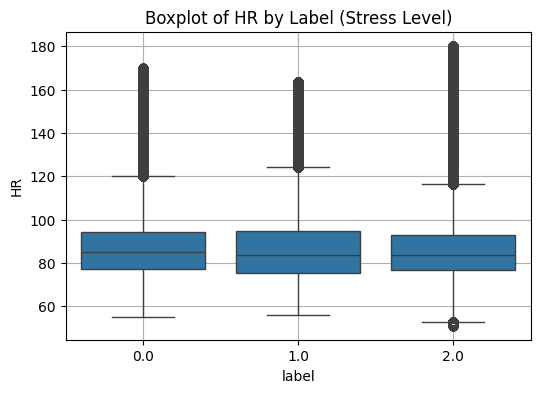

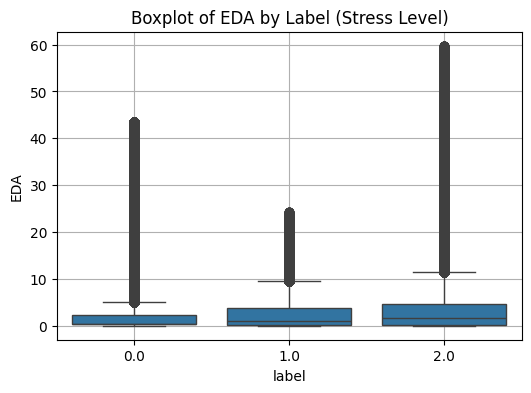

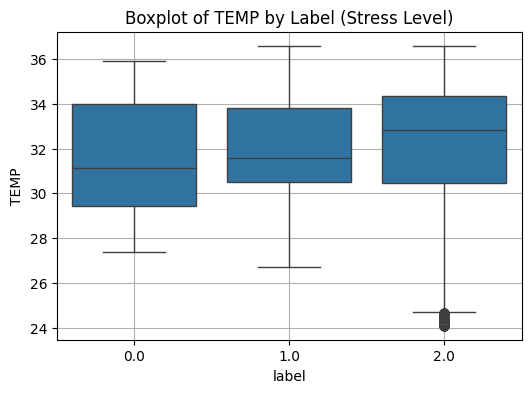

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Choose features to visualize
selected_features = ['HR', 'EDA', 'TEMP']

for feature in selected_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='label', y=feature, data=merged_data)
    plt.title(f'Boxplot of {feature} by Label (Stress Level)')
    plt.grid(True)
    plt.show()


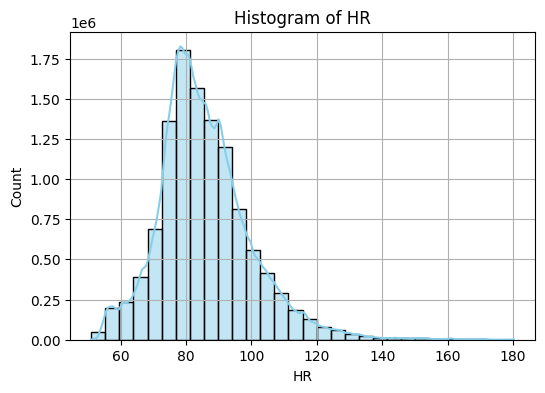

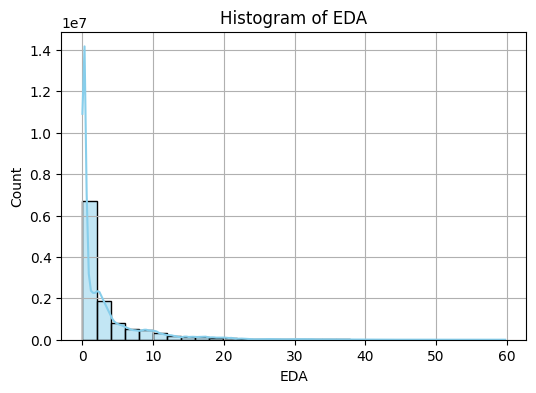

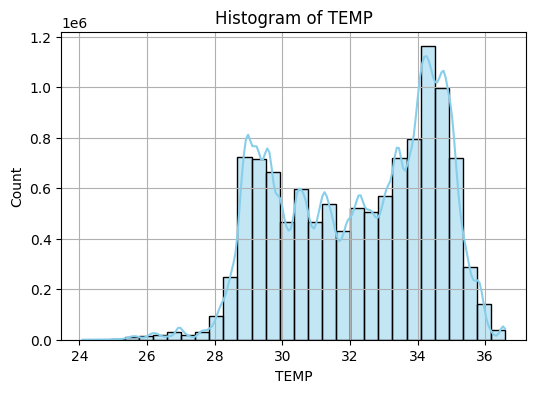

In [16]:
# Plot histograms for selected features
for feature in selected_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(merged_data[feature], kde=True, bins=30, color='skyblue')
    plt.title(f'Histogram of {feature}')
    plt.grid(True)
    plt.show()


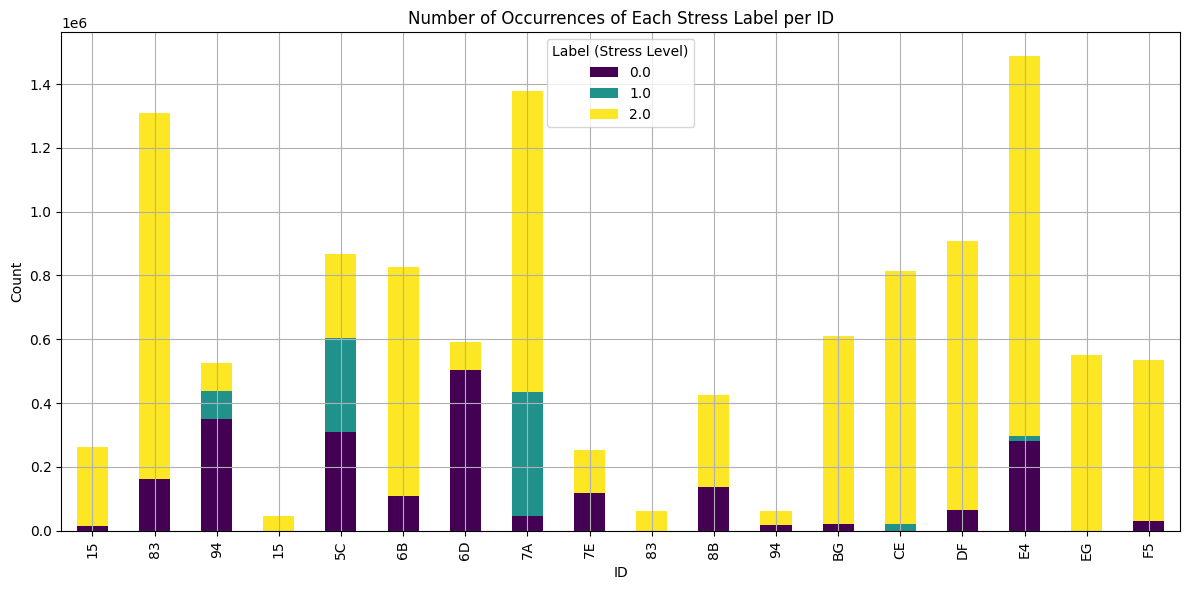

In [17]:
# Make sure 'id' column is present
if 'id' in merged_data.columns:
    count_data = merged_data.groupby(['id', 'label']).size().unstack(fill_value=0)

    count_data.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
    plt.title('Number of Occurrences of Each Stress Label per ID')
    plt.xlabel('ID')
    plt.ylabel('Count')
    plt.legend(title='Label (Stress Level)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️ No 'id' column found in data.")


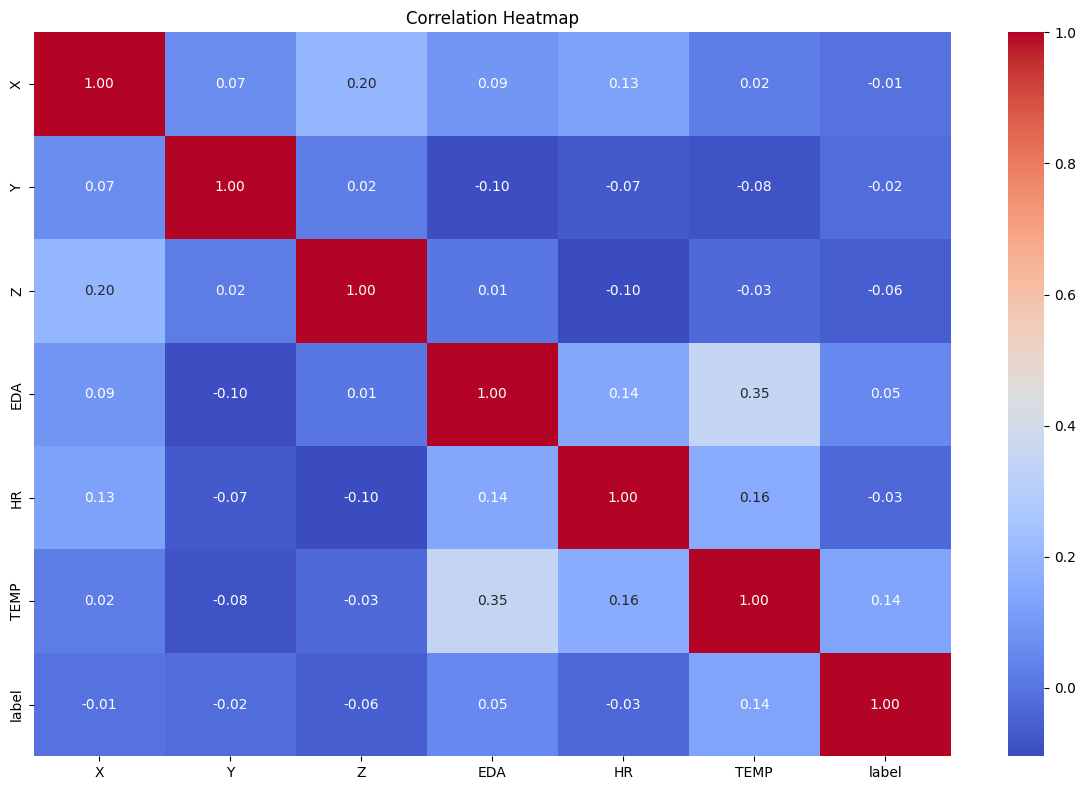

In [18]:
# Compute correlation matrix for numeric features
plt.figure(figsize=(12, 8))
correlation = merged_data.select_dtypes(include='number').corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


In [19]:
# Group by stress label and describe
grouped_stats = merged_data.groupby('label')[selected_features].describe()
grouped_stats


HR                                                            \
           count       mean        std    min    25%    50%    75%     max   
label                                                                        
0.0    2162246.0  86.615423  12.936919  55.13  77.20  84.88  94.32  169.93   
1.0     806222.0  86.452402  15.435209  55.92  75.23  83.48  94.82  163.50   
2.0    8540583.0  85.479283  14.367178  51.00  76.75  83.67  92.67  180.23   

             EDA            ...                            TEMP             \
           count      mean  ...       75%        max      count       mean   
label                       ...                                              
0.0    2162246.0  2.950669  ...  2.215541  43.563389  2162246.0  31.638143   
1.0     806222.0  3.068973  ...  3.886085  24.167313   806222.0  31.987733   
2.0    8540583.0  3.682631  ...  4.691137  59.760712  8540583.0  32.408568   

                                                    
            std    min    25%    50%    75%    max  
label                                               
0.0    2.321948  27.39  29.43  31.11  34.00  35.91  
1.0    2.332756  26.71  30.51  31.59  33.81  36.59  
2.0    2.209356  24.09  30.47  32.81  34.33  36.57  

[3 rows x 24 columns]

In [20]:
# Convert 'datetime' to proper datetime format
merged_data['datetime'] = pd.to_datetime(merged_data['datetime'], errors='coerce')

# Check for conversion success
print("Datetime conversion complete.")
print(merged_data['datetime'].head())


Datetime conversion complete.
0   2020-07-08 14:03:00.000000000
1   2020-07-08 14:03:00.031249920
2   2020-07-08 14:03:00.062500096
3   2020-07-08 14:03:00.093750016
4   2020-07-08 14:03:00.124999936
Name: datetime, dtype: datetime64[ns]


In [21]:
# Check missing values
missing_counts = merged_data.isnull().sum()
print("Missing value counts per column:\n", missing_counts)

# Drop rows with missing values (if few) or handle accordingly
merged_data = merged_data.dropna()
print(f"✅ Data shape after dropping missing values: {merged_data.shape}")


Missing value counts per column:
 X           0
Y           0
Z           0
EDA         0
HR          0
TEMP        0
id          0
datetime    0
label       0
dtype: int64
✅ Data shape after dropping missing values: (11509051, 9)


In [22]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return df[(df[column] >= lower) & (df[column] <= upper)]

for col in ['HR', 'EDA', 'TEMP']:
    before = merged_data.shape[0]
    merged_data = remove_outliers(merged_data, col)
    after = merged_data.shape[0]
    print(f"Removed {before - after} outliers from '{col}'")

print(f"✅ Data shape after outlier removal: {merged_data.shape}")


Removed 313700 outliers from 'HR'
Removed 1168886 outliers from 'EDA'
Removed 0 outliers from 'TEMP'
✅ Data shape after outlier removal: (10026465, 9)


In [23]:
from sklearn.preprocessing import StandardScaler

# Select features for scaling
features_to_scale = ['X', 'Y', 'Z', 'EDA', 'HR', 'TEMP']
scaler = StandardScaler()
merged_data[features_to_scale] = scaler.fit_transform(merged_data[features_to_scale])

print("✅ Feature scaling completed using StandardScaler.")
merged_data[features_to_scale].describe()


✅ Feature scaling completed using StandardScaler.


,X,Y,Z,EDA,HR,TEMP
count,1.002646e+07,1.002646e+07,1.002646e+07,1.002646e+07,1.002646e+07,1.002646e+07
mean,1.486274e-16,-5.184043e-17,-1.424138e-17,-6.474838e-16,8.260452e-15,1.001894e-14
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-3.252544e+00,-3.893763e+00,-5.168526e+00,-8.089860e-01,-2.566453e+00,-3.277053e+00
25%,-7.569084e-01,-4.884456e-01,-6.651668e-01,-7.315969e-01,-6.588703e-01,-9.463828e-01
50%,-1.579559e-01,5.883750e-02,5.127665e-02,-5.100101e-01,-1.009466e-01,8.344817e-02
75%,4.742719e-01,5.149068e-01,8.700692e-01,4.125119e-01,6.311267e-01,9.235735e-01
max,5.232617e+00,3.859415e+00,3.531145e+00,3.317403e+00,2.704797e+00,1.899203e+00


In [24]:
# Save preprocessed data
cleaned_file_path = "/content/drive/MyDrive/Dataset/merged_data/cleaned_merged_data.csv"
merged_data.to_csv(cleaned_file_path, index=False)
print(f"✅ Cleaned data saved to: {cleaned_file_path}")


✅ Cleaned data saved to: /content/drive/MyDrive/Dataset/merged_data/cleaned_merged_data.csv


In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Load preprocessed data
cleaned_file_path = "/content/drive/MyDrive/Dataset/merged_data/cleaned_merged_data.csv"
data = pd.read_csv(cleaned_file_path)

# Encode the 'label' column (if needed)
le = LabelEncoder()
data['label'] = le.fit_transform(data['label'])

# Separate features and target
X = data.drop(columns=['label', 'id', 'datetime'], errors='ignore')
y = data['label']

print(f"✅ Data ready. Features shape: {X.shape}, Target shape: {y.shape}")


<ipython-input-25-7f45aef135a6>:7: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(cleaned_file_path)


✅ Data ready. Features shape: (10026465, 6), Target shape: (10026465,)


In [26]:
from sklearn.model_selection import train_test_split

# 80-20 train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set: {X_train.shape}, Testing set: {X_test.shape}")


✅ Training set: (8021172, 6), Testing set: (2005293, 6)


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC(),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results.append((name, acc))

    print(f"\n📊 Model: {name}")
    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=le.classes_.astype(str)))



📊 Model: Logistic Regression
Accuracy: 0.7359
Classification Report:


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

         0.0       0.24      0.00      0.00    388061
         1.0       0.00      0.00      0.00    141059
         2.0       0.74      1.00      0.85   1476173

    accuracy                           0.74   2005293
   macro avg       0.32      0.33      0.28   2005293
weighted avg       0.59      0.74      0.62   2005293


📊 Model: Random Forest
Accuracy: 0.9963
Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99    388061
         1.0       1.00      0.98      0.99    141059
         2.0       1.00      1.00      1.00   1476173

    accuracy                           1.00   2005293
   macro avg       1.00      0.99      0.99   2005293
weighted avg       1.00      1.00      1.00   2005293



In [ ]:
# Show comparison table
results_df = pd.DataFrame(results, columns=["Model", "Accuracy"])
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)

print("📈 Model Performance Comparison:")
results_df
